In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy as sp
import os

In [9]:
os.chdir(r"C:\Users\hecto\Documents\proyecto supply chain")

The Initial Data Diagnostics and Visualization

In [10]:

df = pd.read_csv(r"C:\Users\hecto\Documents\proyecto supply chain\supply_chain_data.csv")
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


=== DATA QUALITY DIAGNOSTICS ===
Dataset Dimensions: 100 rows, 24 columns
Completely duplicated rows: 0
Null values detected per column:
None


=== UNIQUE VALUES IN CATEGORICAL COLUMNS ===
Column 'Product type': 3 unique categories -> ['haircare' 'skincare' 'cosmetics']
Column 'Customer demographics': 4 unique categories -> ['Non-binary' 'Female' 'Unknown' 'Male']
Column 'Shipping carriers': 3 unique categories -> ['Carrier B' 'Carrier A' 'Carrier C']
Column 'Supplier name': 5 unique categories -> ['Supplier 3' 'Supplier 1' 'Supplier 5' 'Supplier 4' 'Supplier 2']
Column 'Location': 5 unique categories -> ['Mumbai' 'Kolkata' 'Delhi' 'Bangalore' 'Chennai']
Column 'Inspection results': 3 unique categories -> ['Pending' 'Fail' 'Pass']
Column 'Transportation modes': 4 unique categories -> ['Road' 'Air' 'Rail' 'Sea']
Column 'Routes': 3 unique categories -> ['Route B' 'Route C' 'Route A']


=== OUTLIER DETECTION (IQR METHOD) ===
Outliers in 'Price': 0
Outliers in 'Availability': 0
Outliers in

C:\Users\hecto\AppData\Local\Temp\ipykernel_6800\3737940657.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product type', y='Defect rates', data=df, ax=axes[0, 1], palette='Set2')
C:\Users\hecto\AppData\Local\Temp\ipykernel_6800\3737940657.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location', y='Number of products sold', data=location_sales, ax=axes[1, 0], palette='Blues_r')
C:\Users\hecto\AppData\Local\Temp\ipykernel_6800\3737940657.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transportation modes', y='Lead 

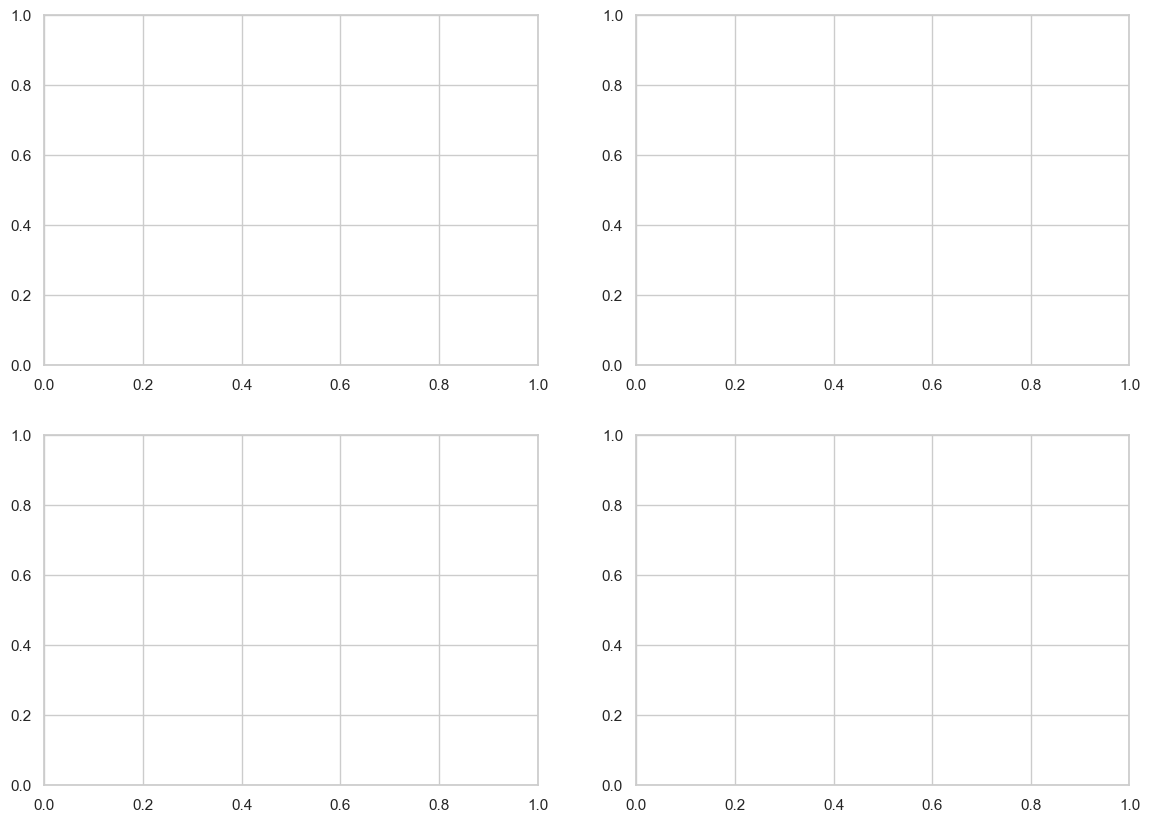

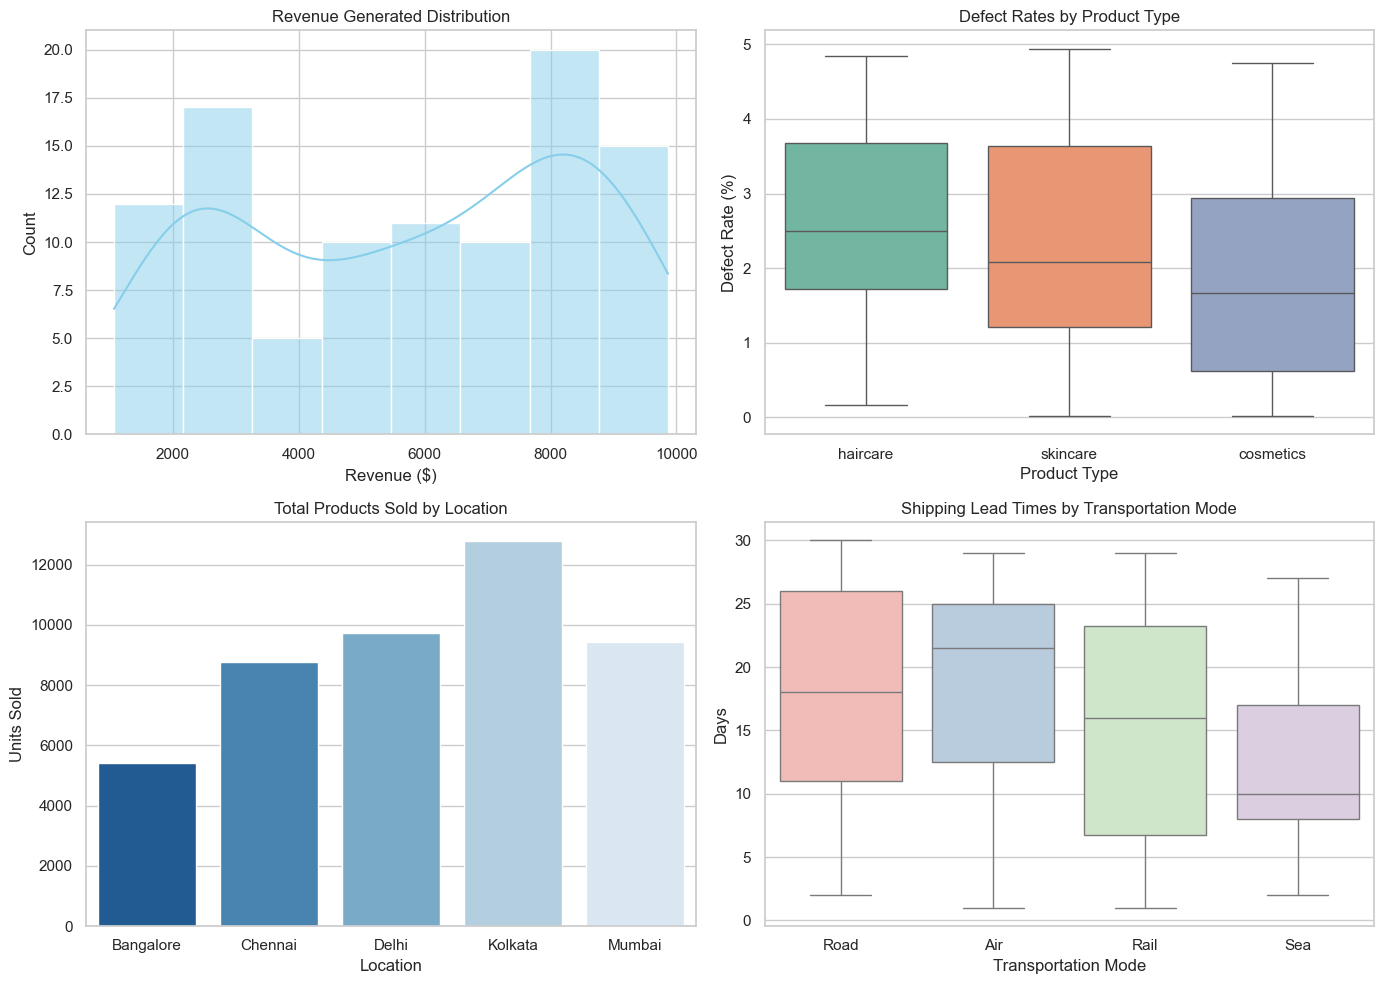

Initial data dashboard successfully generated and saved as 'initial_data_visualization.png'.


In [16]:
# initial visualization
print("=== DATA QUALITY DIAGNOSTICS ===")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Completely duplicated rows: {df.duplicated().sum()}")
null_counts = df.isnull().sum()
#2 null values detected
print(f"Null values detected per column:\n{null_counts[null_counts > 0] if null_counts.sum() > 0 else 'None'}")
print("\n" + "="*40 + "\n")

# 3. Categorical Column Analysis (Unique/Repeated Values)
print("=== UNIQUE VALUES IN CATEGORICAL COLUMNS ===")
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'SKU':  # Exclude unique identifiers like SKU for readability
        print(f"Column '{col}': {df[col].nunique()} unique categories -> {df[col].unique()}")
print("\n" + "="*40 + "\n")

# 4. Statistical Outlier Detection (IQR Method)
print("=== OUTLIER DETECTION (IQR METHOD) ===")
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f"Outliers in '{col}': {outliers}")
print("\n" + "="*40 + "\n")

# 5. Dashboard Generation (Initial Data Visualization)
print("Generating diagnostic visualization plots...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# 5. Dashboard Generation (Initial Data Visualization)
print("Generating diagnostic visualization plots...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Revenue Generated Distribution (Histogram)
sns.histplot(df['Revenue generated'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Revenue Generated Distribution')
axes[0, 0].set_xlabel('Revenue ($)')
axes[0, 0].set_ylabel('Count')

# Plot 2: Defect Rates by Product Type (Boxplot to verify dispersion)
sns.boxplot(x='Product type', y='Defect rates', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Defect Rates by Product Type')
axes[0, 1].set_xlabel('Product Type')
axes[0, 1].set_ylabel('Defect Rate (%)')

# Plot 3: Total Physical Products Sold by Region (Barplot)
location_sales = df.groupby('Location')['Number of products sold'].sum().reset_index()
sns.barplot(x='Location', y='Number of products sold', data=location_sales, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Total Products Sold by Location')
axes[1, 0].set_xlabel('Location')
axes[1, 0].set_ylabel('Units Sold')

# Plot 4: Operational Lead Times by Transportation Mode (Boxplot)
sns.boxplot(x='Transportation modes', y='Lead times', data=df, ax=axes[1, 1], palette='Pastel1')
axes[1, 1].set_title('Shipping Lead Times by Transportation Mode')
axes[1, 1].set_xlabel('Transportation Mode')
axes[1, 1].set_ylabel('Days')

plt.tight_layout()
plt.savefig('initial_data_visualization.png', dpi=300)
plt.show()

print("Initial data dashboard successfully generated and saved as 'initial_data_visualization.png'.")

In [21]:
# 2. Standardize Column Names (convert to lowercase and replace spaces with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("-> Column names standardized to lowercase snake_case.")
    
    # 3. Clean Categorical Text Data
    # Strip leading/trailing whitespaces and standardize text case for consistency
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()
print("-> Categorical columns trimmed of accidental whitespaces.")
    
# 4. Enforce Correct Data Types
# Ensure ID/SKU is treated strictly as a string/object
df['sku'] = df['sku'].astype(str)
    
# Ensure explicitly numerical metrics are correctly typed
float_cols = ['price', 'revenue_generated', 'shipping_costs', 'manufacturing_costs', 'defect_rates', 'costs']
int_cols = ['availability', 'number_of_products_sold', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'production_volumes', 'manufacturing_lead_time']
    
for col in float_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(float)
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(int)
        print("-> Numerical and categorical data types strictly enforced.")
    
# 5. Operational Consistency Check
# Ensure defect rates are not less than 0 and bounded properly (clipping negative anomalies if any)
df['defect_rates'] = df['defect_rates'].clip(lower=0.0)
    
# Ensure negative stock levels or quantities do not exist
df['stock_levels'] = df['stock_levels'].clip(lower=0)
df['order_quantities'] = df['order_quantities'].clip(lower=0)
print("-> Integrity constraints and logical boundaries verified.")

-> Column names standardized to lowercase snake_case.
-> Categorical columns trimmed of accidental whitespaces.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> Numerical and categorical data types strictly enforced.
-> 

In [31]:

df.to_csv(output_path, index=False)
print(f"-> Cleaned dataset successfully saved to: {output_path}\n")


# Execute the pipeline
if __name__ == "__main__":
    import os
# Ensure data directory exists
os.makedirs('data', exist_ok=True)
    
input_file = 'supply_chain_data.csv'
output_file = 'data/cleaned_supply_chain.csv'
    
cleaned_df = clean_supply_chain_data(input_file, output_file)
print("=== CLEANED DATA DEFINITION ===")
print(cleaned_df.info())

-> Cleaned dataset successfully saved to: data/cleaned_supply_chain.csv



NameError: name 'clean_supply_chain_data' is not defined

In [36]:
print("Engineering 10 operational KPIs...")
    
# KPI 1: Total Revenue per SKU (Native metric baseline)
# Accessible via df['revenue_generated']
    
# KPI 2: Gross Profit Margin (%)
df['gross_profit_margin'] = (df['price'] - df['manufacturing_costs']) / df['price']
    
# KPI 3: Stock-to-Order Ratio
df['stock_to_order_ratio'] = df['stock_levels'] / df['order_quantities']
    
# KPI 4: Carrier Cost Efficiency ($ per Unit Shipped)
df['carrier_cost_per_unit'] = df['shipping_costs'] / df['order_quantities']
    
# KPI 5: Total Logistics Cost ($)
df['total_logistics_cost'] = df['costs'] + df['shipping_costs']
    
# KPI 6: Total Lead Time (Days)
df['total_lead_time'] = df['manufacturing_lead_time'] + df['shipping_times']
    
# KPI 7: Production Fulfillment Rate (%)
df['production_fulfillment_rate'] = df['number_of_products_sold'] / df['production_volumes']
    
# KPI 8: Defect Rate Cost Impact ($)
df['defect_cost_impact'] = (df['production_volumes'] * (df['defect_rates'] / 100)) * df['manufacturing_costs']
    
# KPI 9: Revenue to Cost Ratio
df['revenue_to_logistics_cost_ratio'] = df['revenue_generated'] / df['total_logistics_cost']
    
# KPI 10: SKU Availability Rate (%)
df['availability_rate'] = df['availability'] / 100
    
print("KPI calculations completed successfully.")
    
# Display statistics for validation
kpi_columns = [
        'gross_profit_margin', 'stock_to_order_ratio', 'carrier_cost_per_unit', 
        'total_logistics_cost', 'total_lead_time', 'production_fulfillment_rate', 
        'defect_cost_impact', 'revenue_to_logistics_cost_ratio', 'availability_rate'
    ]
    
print("\n=== KPIS OPERATIONAL SUMMARY ===")
print(df[kpi_columns].describe().T[['count', 'mean', 'min', 'max']])

Engineering 10 operational KPIs...
KPI calculations completed successfully.

=== KPIS OPERATIONAL SUMMARY ===
                                 count        mean         min          max
gross_profit_margin              100.0   -2.132715  -32.392516     0.970221
stock_to_order_ratio             100.0    2.302671    0.000000    41.000000
carrier_cost_per_unit            100.0    0.285790    0.015591     5.237655
total_logistics_cost             100.0  534.793931  107.717501  1004.467988
total_lead_time                  100.0   20.520000    2.000000    38.000000
production_fulfillment_rate      100.0    1.028426    0.008239     4.425121
defect_cost_impact               100.0  623.182627    1.496017  2946.182151
revenue_to_logistics_cost_ratio  100.0   15.453252    1.927017    87.680664
availability_rate                100.0    0.484000    0.010000     1.000000


C:\Users\hecto\AppData\Local\Temp\ipykernel_6800\3315667740.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Defect Cost Impact ($)')

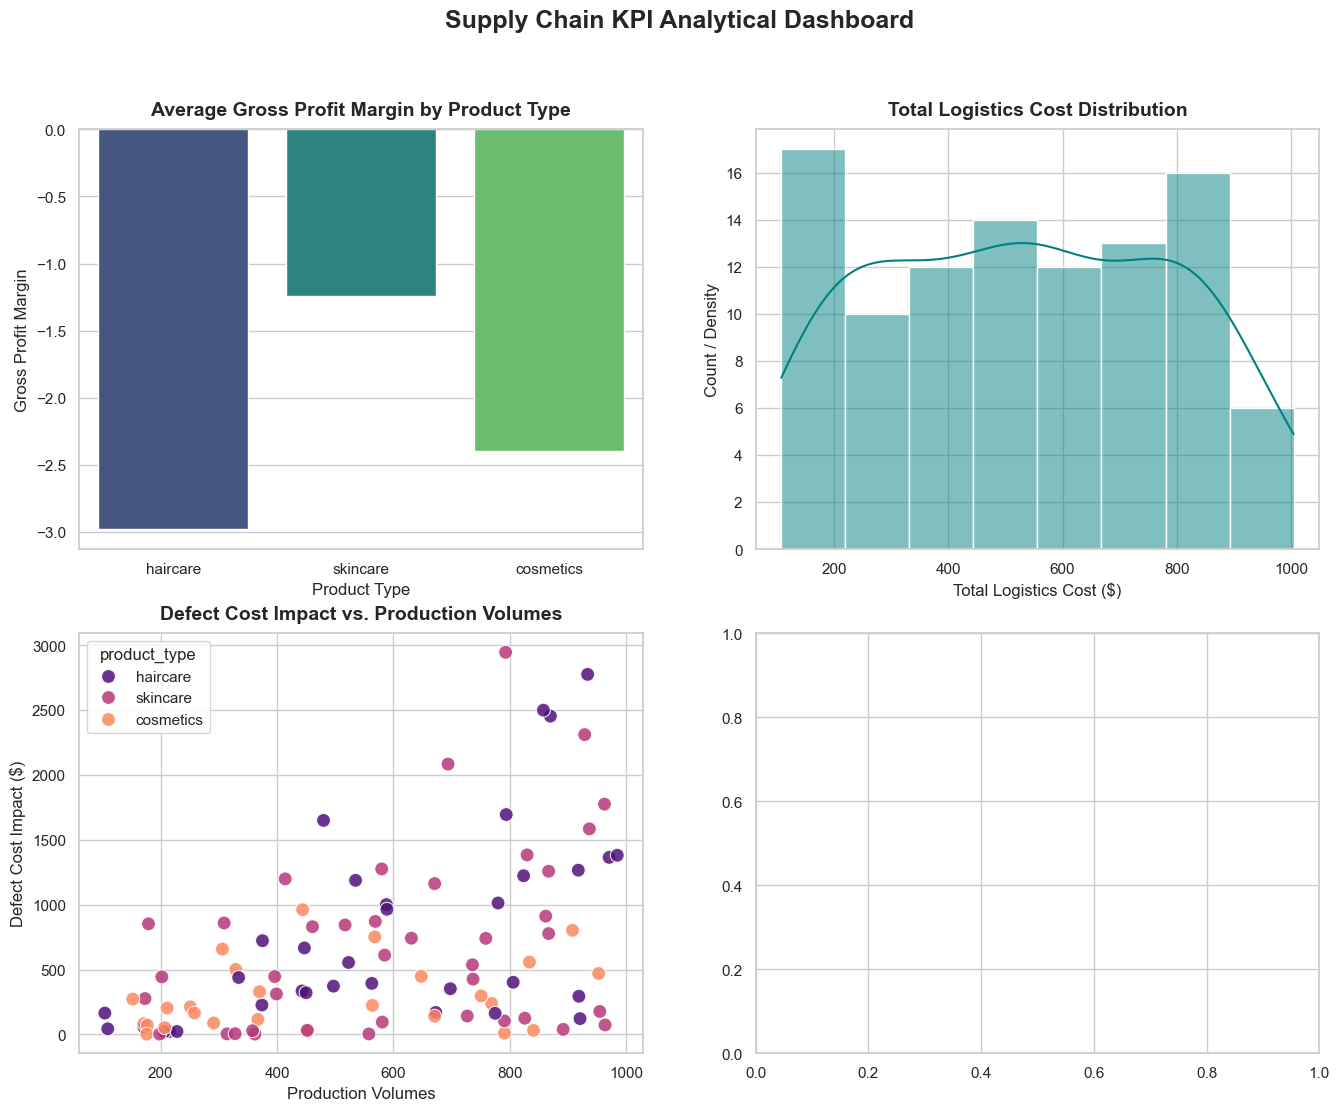

In [42]:
# 2. Re-engineer targeted KPIs for plotting if not already present
df['gross_profit_margin'] = (df['price'] - df['manufacturing_costs']) / df['price']
df['total_logistics_cost'] = df['costs'] + df['shipping_costs']
df['defect_cost_impact'] = (df['production_volumes'] * (df['defect_rates'] / 100)) * df['manufacturing_costs']
df['revenue_to_logistics_cost_ratio'] = df['revenue_generated'] / df['total_logistics_cost']
    
# 3. Configure the plotting layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Supply Chain KPI Analytical Dashboard', fontsize=18, fontweight='bold', y=0.98)
    
# Plot 1: Gross Profit Margin by Product Type
sns.barplot(
    x='product_type', 
    y='gross_profit_margin', 
    data=df, 
    ax=axes[0, 0], 
    palette='viridis', 
    errorbar=None
    )
axes[0, 0].set_title('Average Gross Profit Margin by Product Type', fontsize=14, pad=10, fontweight='semibold')
axes[0, 0].set_xlabel('Product Type', fontsize=12)
axes[0, 0].set_ylabel('Gross Profit Margin', fontsize=12)
    
# Plot 2: Total Logistics Cost Distribution
sns.histplot(
    df['total_logistics_cost'], 
    kde=True, 
    ax=axes[0, 1], 
    color='teal'
    )
axes[0, 1].set_title('Total Logistics Cost Distribution', fontsize=14, pad=10, fontweight='semibold')
axes[0, 1].set_xlabel('Total Logistics Cost ($)', fontsize=12)
axes[0, 1].set_ylabel('Count / Density', fontsize=12)
    
# Plot 3: Defect Cost Impact vs Production Volumes
sns.scatterplot(
    x='production_volumes', 
    y='defect_cost_impact', 
    hue='product_type', 
    data=df, 
    ax=axes[1, 0], 
    palette='magma', 
    s=100, 
    alpha=0.85
    )
axes[1, 0].set_title('Defect Cost Impact vs. Production Volumes', fontsize=14, pad=10, fontweight='semibold')
axes[1, 0].set_xlabel('Production Volumes', fontsize=12)
axes[1, 0].set_ylabel('Defect Cost Impact ($)', fontsize=12)

    

    


In [46]:
df.head()

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,costs,gross_profit_margin,stock_to_order_ratio,carrier_cost_per_unit,total_logistics_cost,total_lead_time,production_fulfillment_rate,defect_cost_impact,revenue_to_logistics_cost_ratio,availability_rate
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,187.752075,0.337041,0.604167,0.030798,190.708648,33,3.730233,22.528225,45.420053,0.55
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,503.065579,-1.264743,1.432432,0.262610,512.782154,32,1.423598,843.630691,14.549843,0.95
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,141.920282,-1.711032,0.011364,0.091528,149.974761,29,0.008239,1364.928048,63.862410,0.34
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,254.776159,0.417548,0.389831,0.029315,256.505728,24,0.088581,1584.449474,30.279388,0.68
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,923.440632,-18.158305,0.089286,0.069474,927.331180,11,2.103865,1198.936896,2.897029,0.26


Machine Learning Model #1:

In [47]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Initializing Machine Learning pipeline using the active 'df'...")

# 1. Define Target (y) and Features (X)
target = 'lead_times'
features = [
    'product_type', 'supplier_name', 'location', 
    'transportation_modes', 'routes', 'production_volumes'
]

# Extract features and target from your existing dataframe
X = df[features]
y = df[target]

# 2. Separate categorical and numerical columns for processing
categorical_cols = ['product_type', 'supplier_name', 'location', 'transportation_modes', 'routes']
numerical_cols = ['production_volumes']

# 3. Create the preprocessing transformer (One-Hot Encoding for text categories)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 4. Build the complete Machine Learning Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train the model
print("Training Random Forest Regressor...")
model_pipeline.fit(X_train, y_train)

# 7. Make predictions on the test data
y_pred = model_pipeline.predict(X_test)

# 8. Evaluate the model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*40)
print("=== MODEL EVALUATION METRICS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R-squared (R2): {r2:.4f}")
print("="*40 + "\n")

# 9. Display a quick side-by-side comparison of Actual vs. Predicted values
comparison_df = pd.DataFrame({
    'Actual_Lead_Time': y_test, 
    'Predicted_Lead_Time': np.round(y_pred, 1)
}).reset_index(drop=True)

print("=== SAMPLE PREDICTIONS (FIRST 5 ROWS) ===")
print(comparison_df.head())

Initializing Machine Learning pipeline using the active 'df'...
Training Random Forest Regressor...

=== MODEL EVALUATION METRICS ===
Mean Absolute Error (MAE): 6.96 days
Root Mean Squared Error (RMSE): 8.55 days
R-squared (R2): 0.1376

=== SAMPLE PREDICTIONS (FIRST 5 ROWS) ===
   Actual_Lead_Time  Predicted_Lead_Time
0                24                 15.8
1                25                 20.1
2                12                 12.5
3                 7                 14.1
4                19                 16.5


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Initializing Classification pipeline using the active 'df'...")

# 1. Define Target (y) and Features (X)
target_class = 'inspection_results'
features_class = [
    'supplier_name', 'product_type', 
    'manufacturing_costs', 'production_volumes', 'defect_rates'
]

# Extract features and target from your existing dataframe
X_clf = df[features_class]
y_clf = df[target_class]

# 2. Separate categorical and numerical columns for processing
categorical_cols_clf = ['supplier_name', 'product_type']
numerical_cols_clf = ['manufacturing_costs', 'production_volumes', 'defect_rates']

# 3. Create the preprocessing transformer (One-Hot Encoding for text categories)
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols_clf),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_clf)
    ])

# 4. Build the complete Classification Pipeline
classification_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_clf),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# 5. Split the data (80% for training, 20% for testing)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 6. Train the Classification model
print("Training Random Forest Classifier...")
classification_pipeline.fit(X_train_clf, y_train_clf)

# 7. Make predictions on the test data
y_pred_clf = classification_pipeline.predict(X_test_clf)

# 8. Evaluate the model performance
accuracy = accuracy_score(y_test_clf, y_pred_clf)
class_report = classification_report(y_test_clf, y_pred_clf)

print("\n" + "="*50)
print("=== CLASSIFICATION MODEL METRICS ===")
print(f"Overall Accuracy: {accuracy:.4f} ({(accuracy*100):.2f}%)")
print("-" * 50)
print("Detailed Classification Report:")
print(class_report)
print("="*50 + "\n")

# 9. Display a quick side-by-side comparison of Actual vs. Predicted values
comparison_clf_df = pd.DataFrame({
    'Actual_Inspection': y_test_clf, 
    'Predicted_Inspection': y_pred_clf
}).reset_index(drop=True)

print("=== SAMPLE CLASSIFICATION PREDICTIONS (FIRST 10 ROWS) ===")
print(comparison_clf_df.head(10))

Initializing Classification pipeline using the active 'df'...
Training Random Forest Classifier...

=== CLASSIFICATION MODEL METRICS ===
Overall Accuracy: 0.5000 (50.00%)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

        Fail       0.40      0.57      0.47         7
        Pass       0.75      0.60      0.67         5
     Pending       0.50      0.38      0.43         8

    accuracy                           0.50        20
   macro avg       0.55      0.52      0.52        20
weighted avg       0.53      0.50      0.50        20


=== SAMPLE CLASSIFICATION PREDICTIONS (FIRST 10 ROWS) ===
  Actual_Inspection Predicted_Inspection
0           Pending                 Pass
1           Pending                 Fail
2           Pending                 Fail
3           Pending              Pending
4              Pass                 Pass
5              Pass                 Fail
6              Fail

Initializing K-Means Unsupervised Clustering pipeline...


C:\Users\hecto\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


SKU Segmentation completed successfully.

=== GENERATED CLUSTER PROFILES (OPERATIONAL AVERAGES) ===
                 price  number_of_products_sold  revenue_generated
sku_cluster                                                       
0            77.760936               463.250000        7761.675344
1            52.769259               496.685714        2639.329989
2            18.514307               420.939394        7177.413882



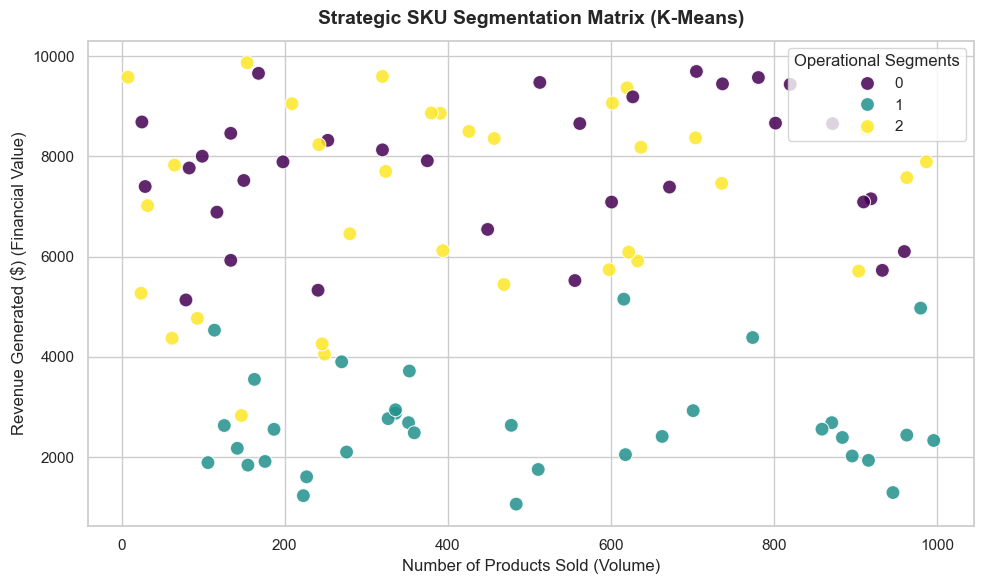

Segmentation visualization successfully saved as 'sku_segmentation_matrix.png


In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Initializing K-Means Unsupervised Clustering pipeline...")

# 1. Select key performance metrics for strategic inventory profiling
features_clustering = ['price', 'number_of_products_sold', 'revenue_generated']
X_cluster = df[features_clustering]

# 2. Scale features to have mean=0 and variance=1 (Critical step for K-Means distance calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Train K-Means Clustering Algorithm with 3 operational groups
optimal_clusters = 3
kmeans_model = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
df['sku_cluster'] = kmeans_model.fit_predict(X_scaled)

print("SKU Segmentation completed successfully.\n")

# 4. Calculate operational averages per cluster to define profile types
cluster_profiles = df.groupby('sku_cluster')[features_clustering].mean()
print("=== GENERATED CLUSTER PROFILES (OPERATIONAL AVERAGES) ===")
print(cluster_profiles)
print("="*60 + "\n")

# 5. Generate Cluster Dashboard Plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='number_of_products_sold', 
    y='revenue_generated', 
    hue='sku_cluster', 
    data=df, 
    palette='viridis', 
    s=100, 
    alpha=0.85
)

plt.title('Strategic SKU Segmentation Matrix (K-Means)', fontsize=14, pad=12, fontweight='bold')
plt.xlabel('Number of Products Sold (Volume)', fontsize=12)
plt.ylabel('Revenue Generated ($) (Financial Value)', fontsize=12)
plt.legend(title='Operational Segments', loc='upper right')
plt.tight_layout()

# Save image for your GitHub repository
plt.savefig('sku_segmentation_matrix.png', dpi=300)
plt.show()

print("Segmentation visualization successfully saved as 'sku_segmentation_matrix.png")